# Lorenz Part 1 — Multi-trajectory GLS

This notebook compares high- and low-fidelity ensembles for the Lorenz system using the multi-trajectory (Part 1) workflow.

## Governing equations

The classic Lorenz-63 dynamics are

$$
\begin{align*}
\dot{x} &= \sigma (y - x), \\
\dot{y} &= x (\rho - z) - y, \\
\dot{z} &= x y - \beta z.
\end{align*}
$$

We use $(\sigma,\rho,\beta) = (10, 28, 8/3)$ with $n_{HF}$ high-fidelity and $n_{LF}$ low-fidelity trajectories.


In [1]:
import warnings
from pathlib import Path

import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401 (register 3D projection)
import numpy as np
import pandas as pd
import seaborn as sns

from mfsindy.cases.lorenz import (
    LorenzMultiTrajectoryGLSConfig,
    generate_lorenz_dataset,
    run_lorenz_multi_trajectory_gls_experiment,
)
from mfsindy.cases.lorenz_plots import COLORS_MODELS
from mfsindy.plots import bubble_hist

warnings.filterwarnings("ignore")
sns.set(context="paper", style="white")

RESULTS_DIR = Path("examples") / "lorenz" / "results"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

MODELS = ["HF", "LF", "MF", "MF_w"]
PLOT_ORDER = ["MF_w", "MF", "HF", "LF"]




In [2]:
cfg = LorenzMultiTrajectoryGLSConfig(
    n_runs=5,
    results_dir=str(RESULTS_DIR),
    results_filename="lorenz_part1_errors.csv",
)

print(
    f"Running Part 1 Lorenz experiment with n_LF={cfg.n_lf}, n_HF={cfg.n_hf}, "
    f"noise_rel(LF)={cfg.noise_lf_rel}, noise_rel(HF)={cfg.noise_hf_rel}."
)

(
    _df_errors,
    _mae_errors,
    _l0_errors,
    state_std,
    noise_hf_abs,
    noise_lf_abs,
) = run_lorenz_multi_trajectory_gls_experiment(cfg)

errors_path = Path(cfg.results_dir) / cfg.results_filename
df_errors = pd.read_csv(errors_path)

def metric_values(metric: str) -> dict[str, np.ndarray]:
    return {
        m: df_errors[(df_errors["model"] == m) & (df_errors["metric"] == metric)]["value"].to_numpy()/27
        for m in MODELS
    }

def summarise(errors: dict[str, np.ndarray]) -> pd.DataFrame:
    rows = []
    for model, values in errors.items():
        arr = np.asarray(values, dtype=float)
        if arr.size == 0:
            continue
        rows.append(
            {
                "model": model,
                "median": float(np.median(arr)),
                "q25": float(np.percentile(arr, 25.0)),
                "q75": float(np.percentile(arr, 75.0)),
            }
        )
    return pd.DataFrame(rows).set_index("model")

mae_errors = metric_values("MAE")
l0_errors = metric_values("L0")
mae_summary = summarise(mae_errors)
l0_summary = summarise(l0_errors)
print(mae_summary)
print(l0_summary)


Running Part 1 Lorenz experiment with n_LF=100, n_HF=10, noise_rel(LF)=0.25, noise_rel(HF)=0.01.


Monte Carlo Lorenz MF:   0%|          | 0/5 [00:00<?, ?it/s]

MODEL HF:
(x0)' =  6.198 x1
(x1)' =  2.965 x0 +  0.422 x1
(x2)' = -2.713 x2 +  1.072 x0 x1
MODEL LF:
(x0)' =  24.887 x0 +  6.954 x1 + -1.253 x0 x2
(x1)' =  3.403 x0
(x2)' = -1.513 x0 + -3.700 x2 +  0.599 x1^2
MODEL MF:
(x0)' =  22.218 x0 +  7.235 x1 + -1.142 x0 x2
(x1)' =  3.491 x0
(x2)' = -1.130 x0 +  0.555 x1 + -3.531 x2 +  0.550 x1^2


Monte Carlo Lorenz MF:  20%|██        | 1/5 [00:14<00:57, 14.36s/it]

MODEL MFW:
(x0)' = -9.591 x0 +  10.086 x1
(x1)' =  3.384 x0
(x2)' = -2.710 x2 +  1.059 x0 x1
MODEL HF:
(x0)' =  0.000
(x1)' =  3.894 x0
(x2)' = -2.677 x2 +  0.954 x0 x1
MODEL LF:
(x0)' =  33.791 x0 + -18.654 x1 + -1.860 x0 x2 +  1.201 x1 x2
(x1)' =  5.079 x0 + -3.099 x1
(x2)' = -0.271 x0 + -3.527 x2 +  1.347 x0^2
MODEL MF:
(x0)' =  32.529 x0 + -19.026 x1 + -1.810 x0 x2 +  1.229 x1 x2
(x1)' =  5.123 x0 + -3.164 x1
(x2)' = -3.371 x2 +  1.242 x0^2


...

MODEL MFW:
(x0)' = -9.982 x0 +  10.061 x1
(x1)' =  6.727 x0 + -1.209 x1
(x2)' = -2.768 x2 +  1.133 x0 x1
MODEL HF:
(x0)' =  0.000
(x1)' =  3.626 x0
(x2)' = -2.699 x2 +  1.009 x0 x1
MODEL LF:
(x0)' = -7.444 x0 +  0.540 x1 x2
(x1)' =  49.163 x0 +  0.472 x1 + -1.984 x0 x2
(x2)' =  32.713 x0 + -1.483 x1 + -1.427 x2 + -0.949 x0^2 +  0.856 x0 x1 + -1.417 x0 x2
MODEL MF:
(x0)' = -7.718 x0 +  6.541 x1
(x1)' =  48.021 x0 + -1.922 x0 x2
(x2)' =  26.700 x0 + -1.114 x1 + -1.671 x2 + -0.759 x0^2 +  0.768 x0 x1 + -1.126 x0 x2


Monte Carlo Lorenz MF:  80%|████████  | 4/5 [00:50<00:12, 12.44s/it]

MODEL MFW:
(x0)' = -9.689 x0 +  9.858 x1
(x1)' =  28.916 x0 + -0.629 x1 + -1.052 x0 x2
(x2)' = -2.696 x2 +  0.997 x0 x1
MODEL HF:
(x0)' =  6.153 x1
(x1)' =  4.566 x0
(x2)' = -2.663 x2 +  1.004 x0 x1
MODEL LF:
(x0)' =  26.113 x0 + -1.405 x1 + -0.822 x2 + -1.354 x0 x2 +  0.531 x1 x2
(x1)' =  34.486 x0 +  3.333 x1 + -1.081 x2 + -1.437 x0 x2 +  0.861 x1^2
(x2)' =  1.144 x0 +  0.672 x1 + -4.158 x2 +  0.597 x0^2 +  0.893 x1^2
MODEL MF:
(x0)' =  22.220 x0 + -0.622 x2 + -1.110 x0 x2
(x1)' =  36.668 x0 +  3.282 x1 + -0.907 x2 + -1.545 x0 x2 +  0.831 x1^2
(x2)' =  1.250 x0 +  0.301 x1 + -3.934 x2 +  0.817 x1^2


Monte Carlo Lorenz MF: 100%|██████████| 5/5 [01:03<00:00, 12.77s/it]

MODEL MFW:
(x0)' = -9.511 x0 +  9.982 x1
(x1)' =  31.943 x0 + -1.201 x0 x2
(x2)' = -2.667 x2 +  0.982 x0 x1
         median       q25       q75
model                              
HF     1.642489  1.532479  1.709721
LF     2.589944  2.563764  2.765227
MF     2.363696  2.170715  2.471602
MF_w   0.844284  0.209937  0.924055
         median       q25       q75
model                              
HF     0.148148  0.111111  0.148148
LF     0.222222  0.222222  0.222222
MF     0.185185  0.185185  0.259259
MF_w   0.037037  0.037037  0.037037


### Trajectory snapshot
Preview noisy LF/HF trajectories vs. a long clean reference.


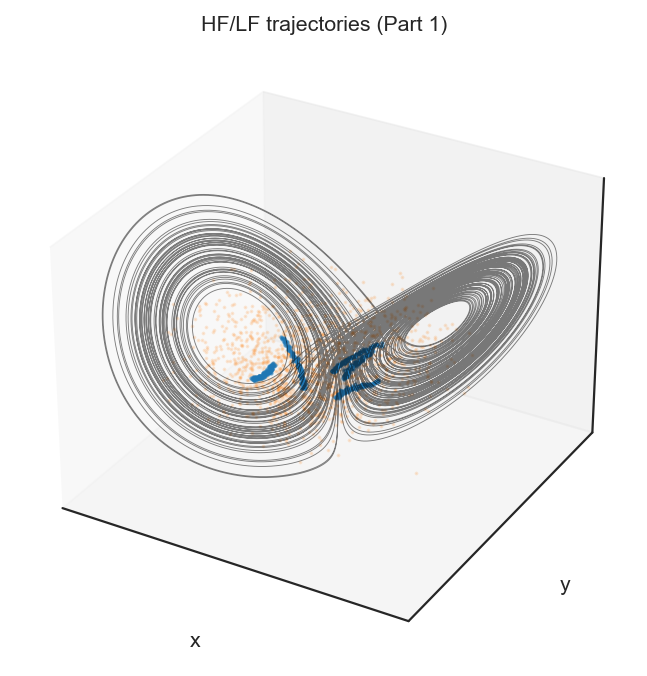

In [3]:
X_hf_batch, t_train, _ = generate_lorenz_dataset(
    n_traj=cfg.n_hf,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=noise_hf_abs,
    seed=cfg.seed_base + 5,
)
X_lf_batch, _, _ = generate_lorenz_dataset(
    n_traj=cfg.n_lf,
    T=cfg.T_train,
    dt=cfg.dt,
    noise_level=noise_lf_abs,
    seed=cfg.seed_base + 125,
)
X_clean, _, _ = generate_lorenz_dataset(
    n_traj=1,
    T=cfg.T_true,
    dt=cfg.dt,
    noise_level=0.0,
    seed=cfg.seed_base,
)

fig = plt.figure(figsize=(5, 5), dpi=160)
ax = fig.add_subplot(111, projection="3d")
ax.set_title("HF/LF trajectories (Part 1)")

for traj in X_lf_batch[: min(15, len(X_lf_batch))]:
    ax.plot(
        traj[:, 0],
        traj[:, 1],
        traj[:, 2],
        ".",
        alpha=0.15,
        color=COLORS_MODELS["LF"],
        markersize=1.4,
    )
for traj in X_hf_batch[: min(5, len(X_hf_batch))]:
    ax.plot(
        traj[:, 0],
        traj[:, 1],
        traj[:, 2],
        ".",
        alpha=0.6,
        color=COLORS_MODELS["HF"],
        markersize=1.8,
    )
ax.plot(
    X_clean[0][:, 0],
    X_clean[0][:, 1],
    X_clean[0][:, 2],
    color="black",
    linewidth=0.4,
    alpha=0.5,
)
ax.set_xticks([]); ax.set_yticks([]); ax.set_zticks([])
ax.set_xlabel("x")
ax.set_ylabel("y")
ax.set_zlabel("z")
ax.grid(False)
plt.show()



### Error summaries
Bubble histograms summarise the MAE and $L_0$ distributions across methods.


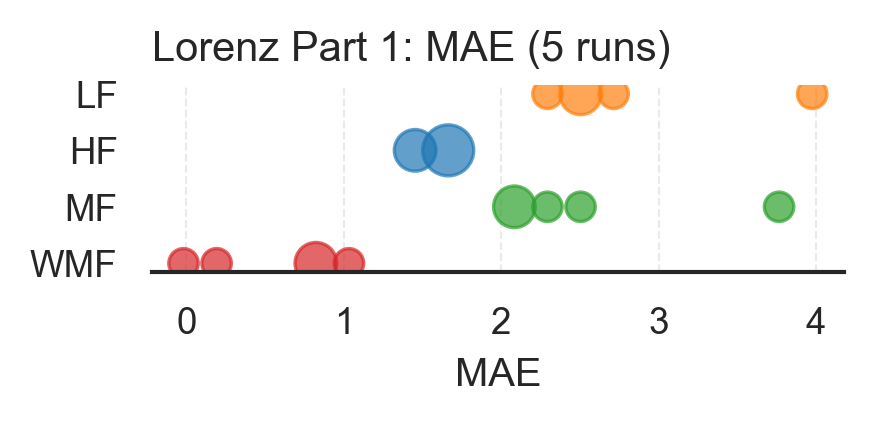

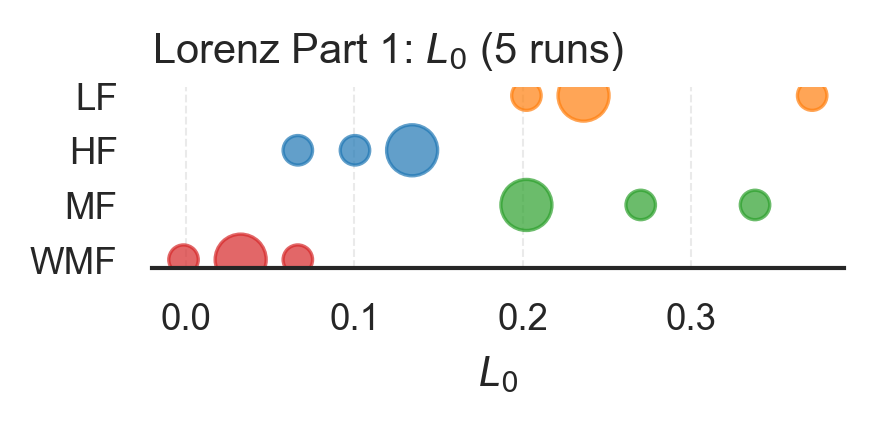

In [5]:
method_colors = {m: COLORS_MODELS.get(m, "tab:gray") for m in MODELS}
labels = ["WMF", "MF", "HF", "LF"]

bubble_hist(
    errors_dict=mae_errors,
    title=f"Lorenz Part 1: MAE ({cfg.n_runs} runs)",
    xlabel="MAE",
    n_bins=20,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

bubble_hist(
    errors_dict=l0_errors,
    title=f"Lorenz Part 1: $L_0$ ({cfg.n_runs} runs)",
    xlabel=r"$L_0$",
    n_bins=12,
    models_order=PLOT_ORDER,
    colors=method_colors,
    labels=labels,
)

